# ✈️ NASA C-MAPSS FD001 — RUL 예측 머신러닝 모델링

**선형 모델 3개** (Ridge / Lasso / ElasticNet) + **트리 모델 3개** (RandomForest / XGBoost / LightGBM)  
**Optuna 하이퍼파라미터 최적화** + **GroupKFold CV (unit 기준)** + **NASA Scoring Function**

| 구분 | 모델 | 피처 전략 | 스케일링 |
|------|------|-----------|----------|
| 선형 | Ridge / Lasso / ElasticNet | 상관관계 필터 (\|r\|>0.95 제거) | ✅ StandardScaler |
| 트리 | RandomForest / XGBoost / LightGBM | 140개 전체 사용 | ❌ 불필요 |


## 0. 환경 설정


In [1]:
import sys, subprocess
for pkg in ['optuna','xgboost','lightgbm','scikit-learn','numpy','pandas','matplotlib','seaborn','joblib']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
print('✅ 라이브러리 설치 완료')


✅ 라이브러리 설치 완료


In [2]:
import os, warnings, time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 한글 폰트 ────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']
plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ────────────────────────────────────────────────────────
DATA_DIR      = 'preprocessed'
RANDOM_STATE  = 42
N_SPLITS_CV   = 5
N_TRIALS_LIN  = 15
N_TRIALS_TRE  = 25
CORR_THR      = 0.95

MODEL_COLORS = {
    'Ridge'        : C[0], 'Lasso'       : C[4],
    'ElasticNet'   : C[5], 'RandomForest': C[2],
    'XGBoost'      : C[1], 'LightGBM'    : C[3],
}

print('✅ 환경 설정 완료')
print(f'   CV={N_SPLITS_CV}fold  |  Corr임계={CORR_THR}  |  선형trials={N_TRIALS_LIN}  |  트리trials={N_TRIALS_TRE}')


c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 환경 설정 완료
   CV=5fold  |  Corr임계=0.95  |  선형trials=15  |  트리trials=25


## 1. 데이터 로드


In [3]:
print('=== 1. 데이터 로드 ===')

# 피처 컬럼 로드
feat_path = os.path.join(DATA_DIR, 'FD001_feature_columns.txt')
with open(feat_path, 'r', encoding='utf-8') as f:
    all_cols = [l.strip() for l in f if l.strip()]
MODEL_FEATURES = [c for c in all_cols if c not in ['unit_nr','time_cycles','RUL']]

# CSV 로드
subtrain = pd.read_csv(os.path.join(DATA_DIR, 'FD001_subtrain_preprocessed.csv'))
valid    = pd.read_csv(os.path.join(DATA_DIR, 'FD001_valid_preprocessed.csv'))

# test_eval (마지막 사이클 + RUL 병합)
eval_path = os.path.join(DATA_DIR, 'FD001_test_eval.csv')
if os.path.exists(eval_path):
    test_eval = pd.read_csv(eval_path)
    print('test_eval: 기존 파일 로드')
else:
    test_full = pd.read_csv(os.path.join(DATA_DIR, 'FD001_test_preprocessed.csv'))
    rul_df    = pd.read_csv(os.path.join(DATA_DIR, 'FD001_test_RUL.csv'))
    test_eval = (test_full.sort_values(['unit_nr','time_cycles'])
                          .groupby('unit_nr').last().reset_index())
    test_eval['RUL'] = rul_df['RUL'].values
    print('test_eval: fallback 생성 (test_full에서 마지막 사이클 추출)')

# 입력/타겟 분리
X_sub   = subtrain[MODEL_FEATURES];   y_sub   = subtrain['RUL']
X_val   = valid[MODEL_FEATURES];      y_val   = valid['RUL']
X_test  = test_eval[MODEL_FEATURES];  y_test  = test_eval['RUL']
groups  = subtrain['unit_nr'].values

print(f'\n피처 수     : {len(MODEL_FEATURES)}개')
print(f'Sub-train   : {subtrain.shape}  | 엔진 {subtrain["unit_nr"].nunique()}대')
print(f'Validation  : {valid.shape}     | 엔진 {valid["unit_nr"].nunique()}대')
print(f'Test (eval) : {test_eval.shape} | 엔진 {test_eval["unit_nr"].nunique()}대')
print(f'\nRUL 통계:')
for name, y in [('Sub-train', y_sub), ('Validation', y_val), ('Test', y_test)]:
    print(f'  {name:12s}: min={y.min():.0f}  max={y.max():.0f}  mean={y.mean():.1f}  std={y.std():.1f}')


=== 1. 데이터 로드 ===
test_eval: 기존 파일 로드

피처 수     : 140개
Sub-train   : (16138, 147)  | 엔진 80대
Validation  : (4493, 147)     | 엔진 20대
Test (eval) : (100, 146) | 엔진 100대

RUL 통계:
  Sub-train   : min=0  max=125  mean=86.0  std=41.7
  Validation  : min=0  max=125  mean=89.9  std=41.3
  Test        : min=7  max=145  mean=75.5  std=41.8


## 2. 피처 준비 — 다중공선성 처리

> **선형 모델**: `|r| > 0.95` 쌍에서 후방 피처 제거 → 축소된 피처 세트 + StandardScaler  
> **트리 모델**: 140개 전체 사용 (다중공선성에 구조적으로 강건)


=== 2. 피처 준비 — 다중공선성 처리 ===
전체 피처         : 140개
제거 피처         :  92개  (|r|>0.95 중복 피처)
선형 모델용 피처  :  48개
트리 모델용 피처  : 140개


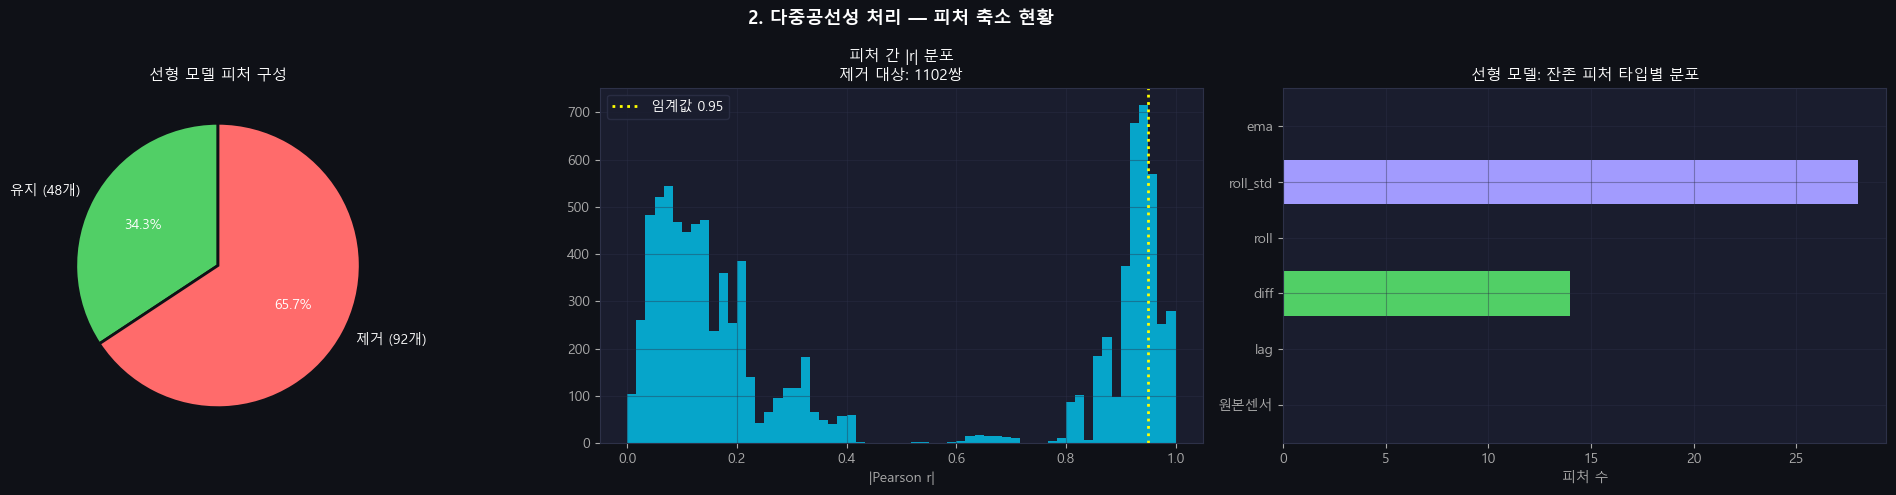


✅ StandardScaler fit (sub-train 기준)
   선형 입력: (16138, 48)  |  트리 입력: (16138, 140)


In [4]:
print('=== 2. 피처 준비 — 다중공선성 처리 ===')

# Sub-train 기준 상관행렬
corr_mat = X_sub.corr().abs()
upper    = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop  = {col for col in upper.columns if any(upper[col] > CORR_THR)}

FEATURES_LINEAR = [f for f in MODEL_FEATURES if f not in to_drop]
FEATURES_TREE   = MODEL_FEATURES

print(f'전체 피처         : {len(MODEL_FEATURES):3d}개')
print(f'제거 피처         : {len(to_drop):3d}개  (|r|>{CORR_THR} 중복 피처)')
print(f'선형 모델용 피처  : {len(FEATURES_LINEAR):3d}개')
print(f'트리 모델용 피처  : {len(FEATURES_TREE):3d}개')

# ── 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('2. 다중공선성 처리 — 피처 축소 현황', fontsize=13, fontweight='bold')

# 파이 차트
wedges,_,auts = axes[0].pie(
    [len(FEATURES_LINEAR), len(to_drop)],
    labels=[f'유지 ({len(FEATURES_LINEAR)}개)', f'제거 ({len(to_drop)}개)'],
    colors=[C[2], C[1]], autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth':2,'edgecolor':BG})
for a in auts: a.set_color(WHITE)
axes[0].set_title('선형 모델 피처 구성')
axes[0].set_facecolor(BG2)

# |r| 분포
corr_vals = upper.stack().values
axes[1].hist(corr_vals[corr_vals > 0], bins=60, color=C[0], alpha=0.75)
axes[1].axvline(CORR_THR, color='yellow', lw=2, ls=':', label=f'임계값 {CORR_THR}')
axes[1].set_title(f'피처 간 |r| 분포\n제거 대상: {(corr_vals > CORR_THR).sum()}쌍')
axes[1].set_xlabel('|Pearson r|'); axes[1].legend()

# 피처 타입별 잔존 현황
kept   = pd.Series(FEATURES_LINEAR)
types  = {'원본센서':kept[~kept.str.contains('_')].count(),
          'lag':    kept[kept.str.contains('lag')].count(),
          'diff':   kept[kept.str.contains('diff')].count(),
          'roll':   kept[kept.str.contains('roll') & ~kept.str.contains('std')].count(),
          'roll_std':kept[kept.str.contains('roll_std')].count(),
          'ema':    kept[kept.str.contains('ema')].count()}
axes[2].barh(list(types.keys()), list(types.values()), color=[C[i%len(C)] for i in range(len(types))])
axes[2].set_title('선형 모델: 잔존 피처 타입별 분포')
axes[2].set_xlabel('피처 수')
plt.tight_layout(); plt.show()

# ── 선형 모델용 데이터 (scaled) ───────────────────────────────────────
scaler_lin = StandardScaler()
Xls_sub  = pd.DataFrame(scaler_lin.fit_transform(X_sub[FEATURES_LINEAR]),  columns=FEATURES_LINEAR, index=X_sub.index)
Xls_val  = pd.DataFrame(scaler_lin.transform(X_val[FEATURES_LINEAR]),      columns=FEATURES_LINEAR, index=X_val.index)
Xls_test = pd.DataFrame(scaler_lin.transform(X_test[FEATURES_LINEAR]),     columns=FEATURES_LINEAR, index=X_test.index)
print(f'\n✅ StandardScaler fit (sub-train 기준)')
print(f'   선형 입력: {Xls_sub.shape}  |  트리 입력: {X_sub.shape}')


## 3. 실험 설계 — CV 전략 & 평가 지표

> **CV**: GroupKFold(5) — unit_nr 기준. 같은 엔진이 Train/Valid에 동시 포함 불가  
> **NASA Score**: 늦은 예측(d≥0)에 더 큰 패널티 → `exp(d/10)-1` vs `exp(-d/13)-1`


In [5]:
print('=== 3. 실험 설계 ===')

gkf = GroupKFold(n_splits=N_SPLITS_CV)

# CV 분포 확인
fold_rows = []
for fold, (ti, vi) in enumerate(gkf.split(X_sub, y_sub, groups), 1):
    fold_rows.append({'Fold':fold, 'Train엔진':len(set(groups[ti])),
                      'Valid엔진':len(set(groups[vi])),
                      'Train행수':len(ti), 'Valid행수':len(vi)})
print('GroupKFold CV 분포:')
display(pd.DataFrame(fold_rows).set_index('Fold'))

# ── 평가 함수 ─────────────────────────────────────────────────────────
def nasa_score(y_true, y_pred):
    d = np.asarray(y_pred, float) - np.asarray(y_true, float)
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

def get_metrics(y_true, y_pred):
    return {
        'RMSE'      : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE'       : float(mean_absolute_error(y_true, y_pred)),
        'R2'        : float(r2_score(y_true, y_pred)),
        'NASA_Score': nasa_score(y_true, y_pred),
    }

def cv_score(model_fn, X, y, grp, scale=False):
    """GroupKFold CV → 평균 RMSE 반환 (Optuna objective용)"""
    rmse_list = []
    for ti, vi in gkf.split(X, y, grp):
        Xtr, Xva = X.iloc[ti].copy(), X.iloc[vi].copy()
        ytr, yva = y.iloc[ti], y.iloc[vi]
        if scale:
            sc = StandardScaler()
            Xtr = sc.fit_transform(Xtr); Xva = sc.transform(Xva)
        m = model_fn(); m.fit(Xtr, ytr)
        rmse_list.append(np.sqrt(mean_squared_error(yva, m.predict(Xva))))
    return float(np.mean(rmse_list))

print('\n✅ 평가 함수 정의 완료')
print('   RMSE / MAE / R² / NASA Score (낮을수록 좋음)')

# 결과 저장 딕셔너리
ALL_RESULTS  = {}   # {모델명: {'cv_rmse','val_metrics','test_metrics','model','study'}}
BEST_MODELS  = {}   # {모델명: fitted model}


=== 3. 실험 설계 ===
GroupKFold CV 분포:


,Train엔진,Valid엔진,Train행수,Valid행수
Fold,,,,
1,64,16,12911,3227
2,64,16,12915,3223
3,64,16,12906,3232
4,64,16,12914,3224
5,64,16,12906,3232



✅ 평가 함수 정의 완료
   RMSE / MAE / R² / NASA Score (낮을수록 좋음)


## 4. 선형 모델 학습 — Ridge / Lasso / ElasticNet (Optuna)

> 다중공선성 필터링된 피처 + StandardScaler 적용  
> Optuna TPE 샘플러로 α, l1_ratio 최적화


In [6]:
print('=== 4. 선형 모델 학습 (Optuna) ===')
print(f'피처 수: {len(FEATURES_LINEAR)}개 (상관관계 필터 후)  |  Trials: {N_TRIALS_LIN}')
print()

def get_linear_model(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha',0.01,500,log=True))
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha',1e-4,10,log=True), max_iter=10000)
    else:  # ElasticNet
        return ElasticNet(
            alpha   =trial.suggest_float('alpha',1e-4,10,log=True),
            l1_ratio=trial.suggest_float('l1_ratio',0.05,0.95),
            max_iter=10000)

linear_models = ['Ridge', 'Lasso', 'ElasticNet']

for mname in linear_models:
    t0 = time.time()
    print(f'  [{mname}] Optuna 최적화 중... ', end='', flush=True)

    def objective(trial):
        m = get_linear_model(trial, mname)
        return cv_score(lambda: get_linear_model(trial, mname), Xls_sub, y_sub, groups, scale=False)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_LIN, show_progress_bar=False)

    # 최적 파라미터로 full sub-train 학습
    best_p = study.best_params
    if mname == 'Ridge':
        best_m = Ridge(**best_p)
    elif mname == 'Lasso':
        best_m = Lasso(**best_p, max_iter=10000)
    else:
        best_m = ElasticNet(**best_p, max_iter=10000)
    best_m.fit(Xls_sub, y_sub)

    cv_rmse = study.best_value
    val_m   = get_metrics(y_val,  best_m.predict(Xls_val))
    test_m  = get_metrics(y_test, best_m.predict(Xls_test))

    ALL_RESULTS[mname] = {
        'cv_rmse':cv_rmse, 'val_metrics':val_m, 'test_metrics':test_m,
        'model':best_m, 'study':study, 'params':best_p, 'type':'linear'
    }
    BEST_MODELS[mname] = best_m

    print(f'완료 ({time.time()-t0:.1f}s)  |  CV RMSE={cv_rmse:.3f}  Params={best_p}')

print('\n✅ 선형 모델 3개 학습 완료')


=== 4. 선형 모델 학습 (Optuna) ===
피처 수: 48개 (상관관계 필터 후)  |  Trials: 15

  [Ridge] Optuna 최적화 중... 완료 (2.7s)  |  CV RMSE=20.535  Params={'alpha': 117.52647960576222}
  [Lasso] Optuna 최적화 중... 완료 (487.3s)  |  CV RMSE=20.538  Params={'alpha': 0.010078914959537243}
  [ElasticNet] Optuna 최적화 중... 완료 (463.7s)  |  CV RMSE=20.534  Params={'alpha': 0.01444525102276306, 'l1_ratio': 0.3121062261782377}

✅ 선형 모델 3개 학습 완료


## 5. 트리 모델 학습 — RandomForest / XGBoost / LightGBM (Optuna)

> 140개 전체 피처 사용 (스케일링 불필요)  
> Optuna TPE 샘플러로 주요 하이퍼파라미터 최적화


In [7]:
print('=== 5. 트리 모델 학습 (Optuna) ===')
print(f'피처 수: {len(FEATURES_TREE)}개  |  Trials: {N_TRIALS_TRE}')
print()

def get_tree_model(trial, name):
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators    =trial.suggest_int('n_estimators',100,600),
            max_depth       =trial.suggest_int('max_depth',5,30),
            min_samples_split=trial.suggest_int('min_samples_split',2,20),
            min_samples_leaf =trial.suggest_int('min_samples_leaf',1,10),
            max_features    =trial.suggest_float('max_features',0.2,1.0),
            random_state=RANDOM_STATE, n_jobs=-1)
    elif name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators   =trial.suggest_int('n_estimators',100,600),
            max_depth      =trial.suggest_int('max_depth',3,10),
            learning_rate  =trial.suggest_float('learning_rate',0.01,0.3,log=True),
            subsample      =trial.suggest_float('subsample',0.5,1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
            reg_alpha      =trial.suggest_float('reg_alpha',1e-8,10,log=True),
            reg_lambda     =trial.suggest_float('reg_lambda',1e-8,10,log=True),
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    else:  # LightGBM
        return lgb.LGBMRegressor(
            n_estimators   =trial.suggest_int('n_estimators',100,600),
            max_depth      =trial.suggest_int('max_depth',3,12),
            learning_rate  =trial.suggest_float('learning_rate',0.01,0.3,log=True),
            num_leaves     =trial.suggest_int('num_leaves',20,200),
            subsample      =trial.suggest_float('subsample',0.5,1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
            reg_alpha      =trial.suggest_float('reg_alpha',1e-8,10,log=True),
            reg_lambda     =trial.suggest_float('reg_lambda',1e-8,10,log=True),
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

tree_models = ['RandomForest','XGBoost','LightGBM']

for mname in tree_models:
    t0 = time.time()
    print(f'  [{mname}] Optuna 최적화 중... ', end='', flush=True)

    def make_obj(mn):
        def objective(trial):
            return cv_score(lambda: get_tree_model(trial, mn), X_sub, y_sub, groups)
        return objective

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(make_obj(mname), n_trials=N_TRIALS_TRE, show_progress_bar=False)

    best_p = study.best_params
    best_m = get_tree_model(type('T',(),{'suggest_int':lambda s,n,lo,hi:best_p.get(n,lo),'suggest_float':lambda s,n,lo,hi,**kw:best_p.get(n,lo)})(), mname)

    # best_params로 직접 모델 생성
    if mname == 'RandomForest':
        best_m = RandomForestRegressor(**best_p, random_state=RANDOM_STATE, n_jobs=-1)
    elif mname == 'XGBoost':
        best_m = xgb.XGBRegressor(**best_p, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    else:
        best_m = lgb.LGBMRegressor(**best_p, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    best_m.fit(X_sub, y_sub)

    cv_rmse = study.best_value
    val_m   = get_metrics(y_val,  best_m.predict(X_val))
    test_m  = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'cv_rmse':cv_rmse, 'val_metrics':val_m, 'test_metrics':test_m,
        'model':best_m, 'study':study, 'params':best_p, 'type':'tree'
    }
    BEST_MODELS[mname] = best_m

    print(f'완료 ({time.time()-t0:.1f}s)  |  CV RMSE={cv_rmse:.3f}')

print('\n✅ 트리 모델 3개 학습 완료')


=== 5. 트리 모델 학습 (Optuna) ===
피처 수: 140개  |  Trials: 25

  [RandomForest] Optuna 최적화 중... 완료 (7305.2s)  |  CV RMSE=17.906
  [XGBoost] Optuna 최적화 중... 완료 (1156.6s)  |  CV RMSE=17.190
  [LightGBM] Optuna 최적화 중... 완료 (339.4s)  |  CV RMSE=17.231

✅ 트리 모델 3개 학습 완료


## 6. 모델 성능 비교


In [8]:
print('=== 6. 모델 성능 비교 ===')

rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        '모델'         : mname,
        '구분'         : '선형' if res['type']=='linear' else '트리',
        'CV RMSE'      : round(res['cv_rmse'], 3),
        'Val RMSE'     : round(res['val_metrics']['RMSE'], 3),
        'Val MAE'      : round(res['val_metrics']['MAE'],  3),
        'Val R²'       : round(res['val_metrics']['R2'],   4),
        'Val NASA'     : round(res['val_metrics']['NASA_Score'], 1),
        'Test RMSE'    : round(res['test_metrics']['RMSE'], 3),
        'Test MAE'     : round(res['test_metrics']['MAE'],  3),
        'Test R²'      : round(res['test_metrics']['R2'],   4),
        'Test NASA'    : round(res['test_metrics']['NASA_Score'], 1),
    })

result_df = pd.DataFrame(rows).set_index('모델')
print('\n전체 모델 성능 (Test RMSE 오름차순):')
display(result_df.sort_values('Test RMSE')
        .style.background_gradient(subset=['Test RMSE','Test NASA'], cmap='RdYlGn_r')
               .background_gradient(subset=['Test R²'], cmap='RdYlGn'))

best_model_name = result_df['Test RMSE'].idxmin()
best_res        = ALL_RESULTS[best_model_name]
print(f'\n🏆 최고 모델: {best_model_name}')
print(f'   Test RMSE={best_res["test_metrics"]["RMSE"]:.3f}  MAE={best_res["test_metrics"]["MAE"]:.3f}  R²={best_res["test_metrics"]["R2"]:.4f}  NASA={best_res["test_metrics"]["NASA_Score"]:.1f}')


=== 6. 모델 성능 비교 ===

전체 모델 성능 (Test RMSE 오름차순):


,구분,CV RMSE,Val RMSE,Val MAE,Val R²,Val NASA,Test RMSE,Test MAE,Test R²,Test NASA
모델,,,,,,,,,,
LightGBM,트리,17.231000,17.745000,13.308000,0.815200,43010.100000,18.022000,13.713000,0.811900,623.300000
RandomForest,트리,17.906000,18.180000,13.453000,0.806100,52681.200000,18.190000,13.369000,0.808400,824.500000
XGBoost,트리,17.190000,17.698000,13.223000,0.816200,40312.300000,18.396000,13.899000,0.804000,647.100000
ElasticNet,선형,20.534000,19.957000,16.145000,0.766300,32084.000000,23.005000,18.472000,0.693500,1771.100000
Ridge,선형,20.535000,19.959000,16.151000,0.766200,32130.700000,23.058000,18.508000,0.692100,1793.700000
Lasso,선형,20.538000,19.958000,16.160000,0.766300,32173.300000,23.088000,18.533000,0.691300,1801.100000



🏆 최고 모델: LightGBM
   Test RMSE=18.022  MAE=13.713  R²=0.8119  NASA=623.3


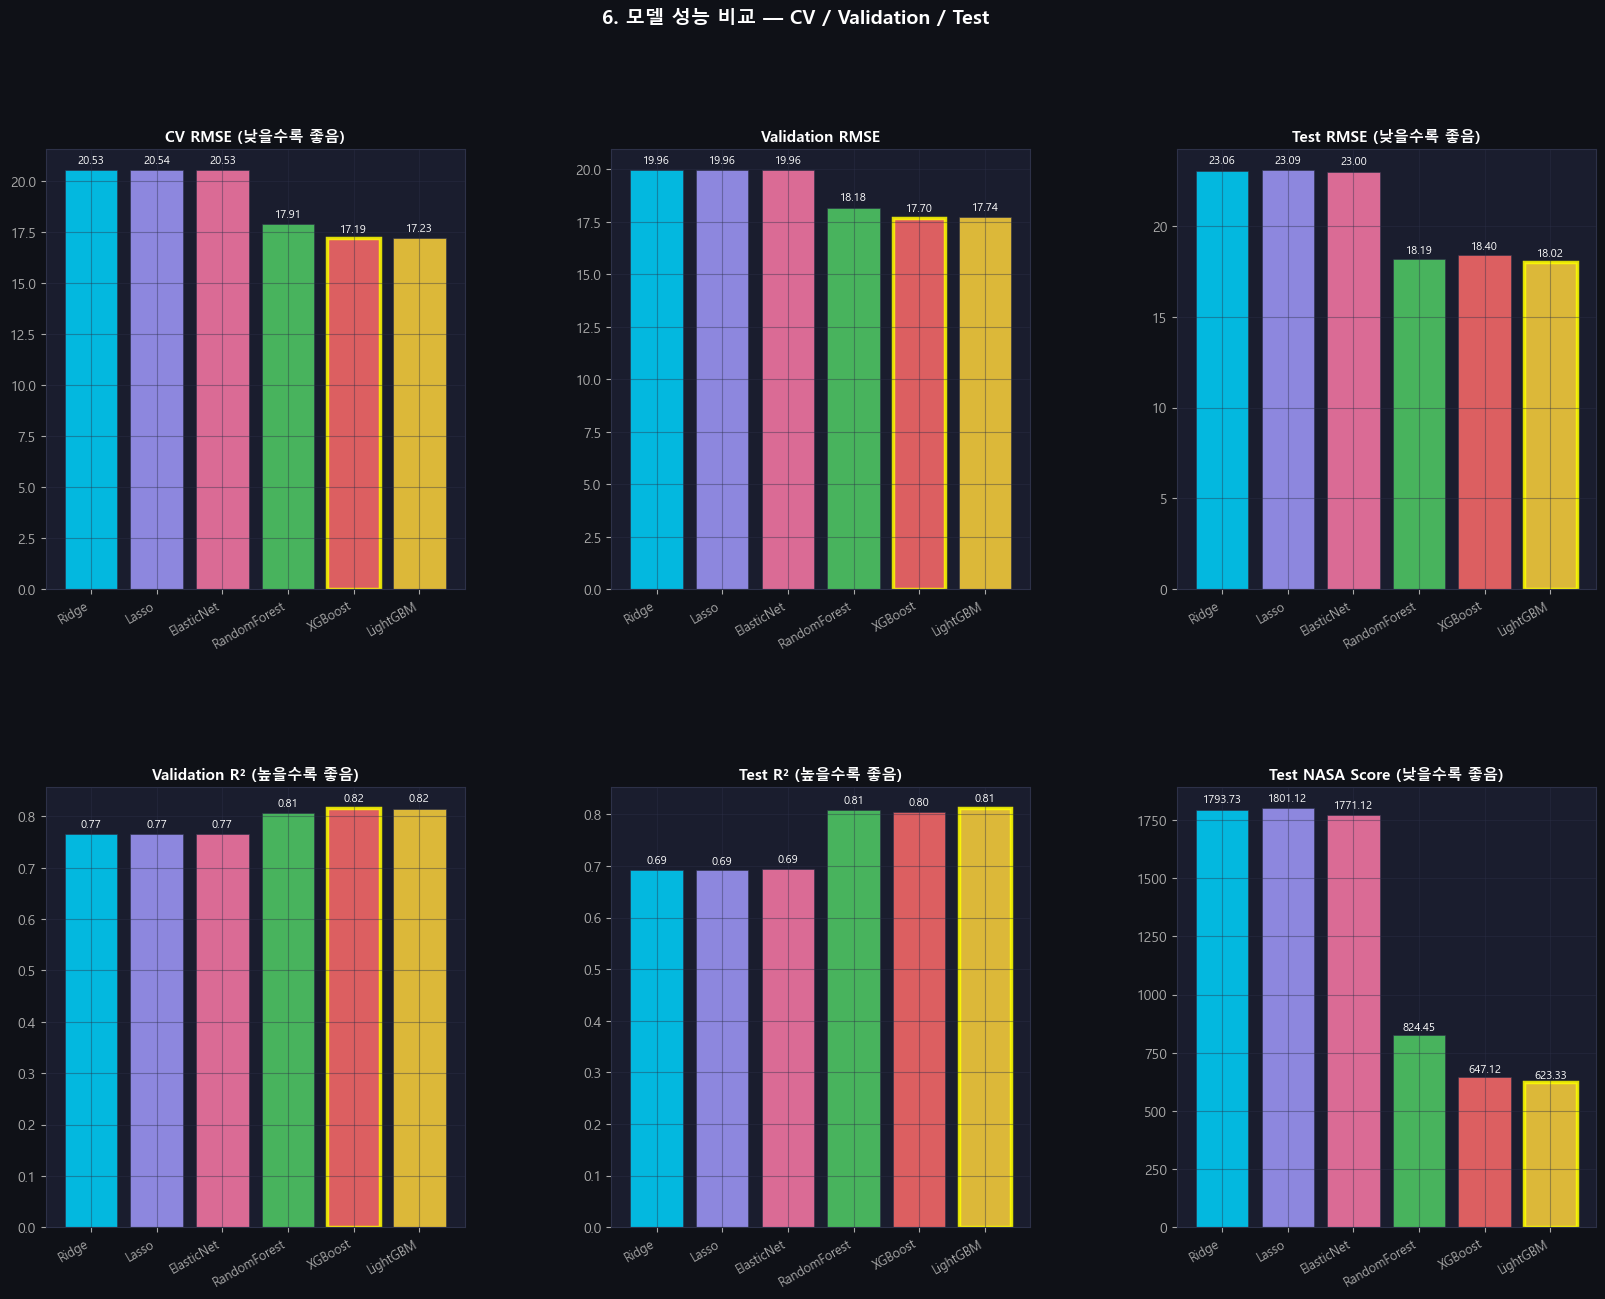

📊 model_comparison.png 저장 완료


In [9]:
# 6가지 모델 성능 시각화
model_names = list(ALL_RESULTS.keys())
colors_bar  = [MODEL_COLORS[m] for m in model_names]

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('6. 모델 성능 비교 — CV / Validation / Test', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

metrics_cfg = [
    ('CV RMSE',   'cv_rmse',           None,           True,  'CV RMSE (낮을수록 좋음)'),
    ('Val RMSE',  'val_metrics.RMSE',  None,           True,  'Validation RMSE'),
    ('Test RMSE', 'test_metrics.RMSE', None,           True,  'Test RMSE (낮을수록 좋음)'),
    ('Val R²',    'val_metrics.R2',    None,           False, 'Validation R² (높을수록 좋음)'),
    ('Test R²',   'test_metrics.R2',   None,           False, 'Test R² (높을수록 좋음)'),
    ('Test NASA', 'test_metrics.NASA_Score', None,     True,  'Test NASA Score (낮을수록 좋음)'),
]

def get_val(res, key):
    if '.' in key:
        a, b = key.split('.')
        return res[a][b]
    return res[key]

for idx, (label, key, _, lower_better, title) in enumerate(metrics_cfg):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    vals = [get_val(ALL_RESULTS[m], key) for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar, alpha=0.85, edgecolor=GRID, linewidth=0.5)

    best_i = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_i].set_edgecolor('yellow'); bars[best_i].set_linewidth(2.5)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, color=WHITE)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_facecolor(BG2)

plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('📊 model_comparison.png 저장 완료')


## 7. Test 세트 상세 평가

> Test 세트 = 엔진 100대 각각의 **마지막 관측 시점**에서 RUL 예측  
> 이것이 C-MAPSS 공식 평가 프로토콜


In [10]:
print('=== 7. Test 세트 상세 평가 (엔진 100대) ===')

test_pred_all = {}
for mname, res in ALL_RESULTS.items():
    model = res['model']
    X_in  = Xls_test if res['type']=='linear' else X_test
    pred  = model.predict(X_in)
    pred  = np.clip(pred, 0, None)  # RUL 음수 방지
    test_pred_all[mname] = pred

# 상세 결과 테이블 (엔진별 예측 오차)
test_detail = test_eval[['unit_nr','time_cycles','RUL']].copy()
for mname, pred in test_pred_all.items():
    test_detail[f'{mname}_pred'] = np.round(pred, 1)
    test_detail[f'{mname}_err']  = np.round(pred - test_detail['RUL'], 1)

print('\n--- 엔진별 예측 결과 (상위 15개) ---')
display(test_detail.head(15))

# 예측 오차 요약
print('\n--- 모델별 Test 오차 요약 ---')
err_summary = []
for mname, pred in test_pred_all.items():
    errs = pred - y_test.values
    err_summary.append({
        '모델': mname,
        '평균 오차(bias)': round(errs.mean(), 2),
        '오차 표준편차': round(errs.std(), 2),
        '조기예측 비율': f'{(errs<0).mean()*100:.1f}%',
        '늦은예측 비율': f'{(errs>0).mean()*100:.1f}%',
        '|오차|≤10 비율': f'{(np.abs(errs)<=10).mean()*100:.1f}%',
        '|오차|≤20 비율': f'{(np.abs(errs)<=20).mean()*100:.1f}%',
    })
display(pd.DataFrame(err_summary).set_index('모델'))


=== 7. Test 세트 상세 평가 (엔진 100대) ===

--- 엔진별 예측 결과 (상위 15개) ---


,unit_nr,time_cycles,RUL,Ridge_pred,Ridge_err,Lasso_pred,Lasso_err,ElasticNet_pred,ElasticNet_err,RandomForest_pred,RandomForest_err,XGBoost_pred,XGBoost_err,LightGBM_pred,LightGBM_err
0,1,31,112,129.8,17.8,130.3,18.3,129.4,17.4,116.9,4.9,118.500000,6.5,119.7,7.7
1,2,49,98,101.5,3.5,101.0,3.0,101.5,3.5,110.8,12.8,113.699997,15.7,113.4,15.4
2,3,126,69,78.7,9.7,78.4,9.4,78.6,9.6,52.7,-16.3,71.400002,2.4,74.8,5.8
3,4,106,82,79.0,-3.0,79.7,-2.3,78.7,-3.3,98.6,16.6,74.099998,-7.9,81.4,-0.6
4,5,98,91,95.1,4.1,94.6,3.6,95.2,4.2,101.1,10.1,102.099998,11.1,101.4,10.4
5,6,105,93,120.6,27.6,121.3,28.3,120.2,27.2,116.2,23.2,123.099998,30.1,121.4,28.4
6,7,160,91,92.1,1.1,91.8,0.8,92.3,1.3,100.8,9.8,94.900002,3.9,98.7,7.7
7,8,166,95,77.6,-17.4,77.6,-17.4,77.6,-17.4,99.0,4.0,92.300003,-2.7,92.1,-2.9
8,9,55,111,105.6,-5.4,105.6,-5.4,105.5,-5.5,103.9,-7.1,99.300003,-11.7,101.2,-9.8
9,10,192,96,98.1,2.1,98.9,2.9,97.6,1.6,91.5,-4.5,92.000000,-4.0,99.1,3.1



--- 모델별 Test 오차 요약 ---


,평균 오차(bias),오차 표준편차,조기예측 비율,늦은예측 비율,|오차|≤10 비율,|오차|≤20 비율
모델,,,,,,
Ridge,7.45,21.77,30.0%,70.0%,36.0%,61.0%
Lasso,7.47,21.79,31.0%,69.0%,36.0%,60.0%
ElasticNet,7.36,21.75,30.0%,70.0%,36.0%,61.0%
RandomForest,0.62,18.18,45.0%,55.0%,52.0%,77.0%
XGBoost,-0.70,18.38,51.0%,49.0%,50.0%,75.0%
LightGBM,0.63,18.01,47.0%,53.0%,50.0%,76.0%


## 8. 잔차 분석 — RUL 구간별 오차 패턴

> 모델이 어느 RUL 구간에서 틀리는지 분석.  
> 초기(RUL>80) / 중기(30<RUL≤80) / 말기(RUL≤30) 구분


=== 8. 잔차 분석 ===


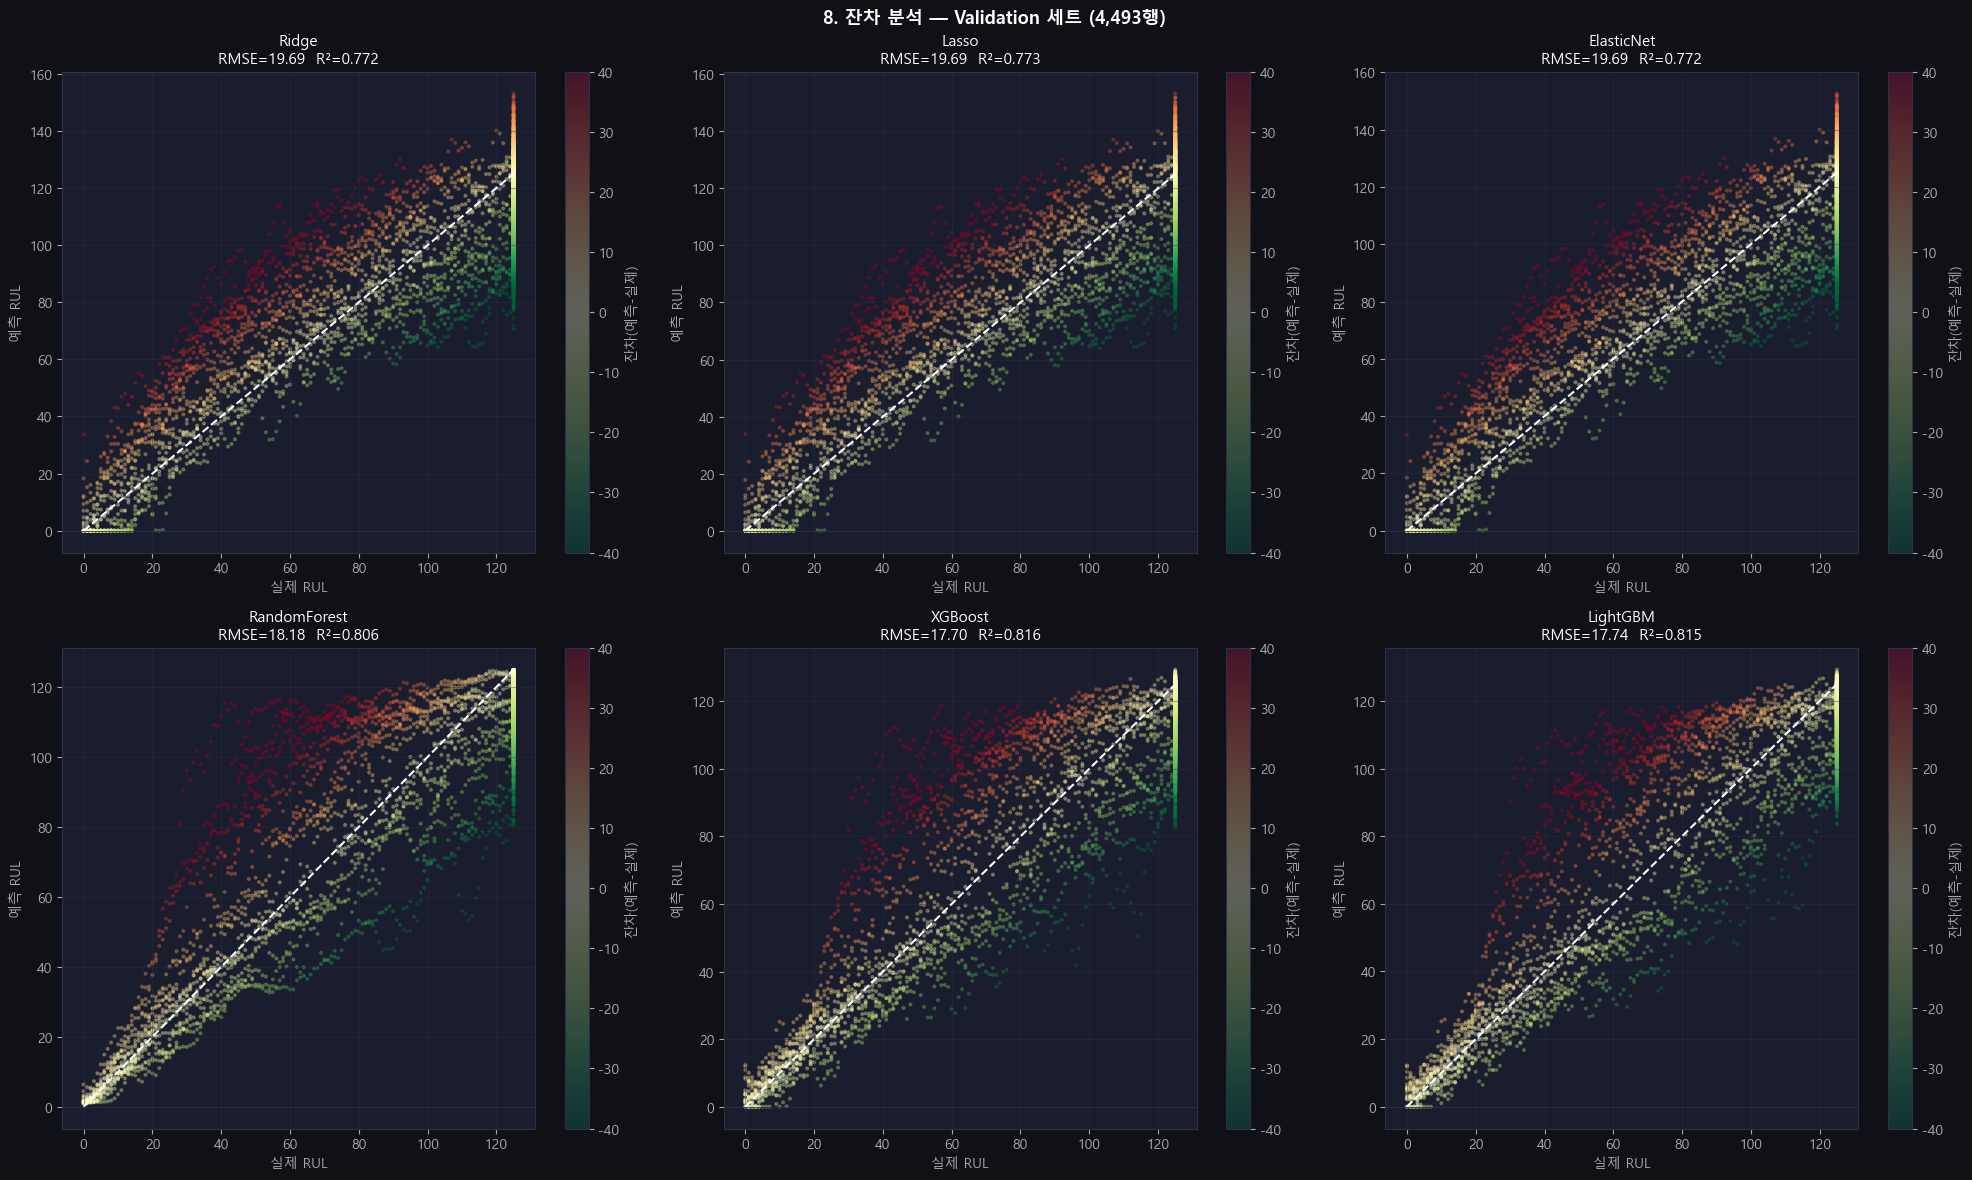


--- RUL 구간별 평균 절대 오차 (MAE) ---


,말기(0~30),중기(31~80),초기(81~125)
모델,,,
Ridge,12.000000,18.010000,15.960000
Lasso,12.020000,18.000000,15.960000
ElasticNet,12.000000,18.030000,15.940000
RandomForest,5.940000,20.870000,12.520000
XGBoost,5.600000,20.600000,12.290000
LightGBM,5.870000,21.120000,12.190000



📌 말기(RUL≤30) MAE가 클수록 위험 구간 예측이 부정확함 → 핵심 개선 포인트


In [11]:
print('=== 8. 잔차 분석 ===')

# Validation 전체 데이터로 잔차 분석 (충분한 샘플 확보)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('8. 잔차 분석 — Validation 세트 (4,493행)', fontsize=13, fontweight='bold')

for idx, (mname, res) in enumerate(ALL_RESULTS.items()):
    ax  = axes[idx//3, idx%3]
    m   = res['model']
    Xin = Xls_val if res['type']=='linear' else X_val
    pred_val = np.clip(m.predict(Xin), 0, None)
    resid    = pred_val - y_val.values

    # 산점도 (실제 vs 예측)
    sc = ax.scatter(y_val, pred_val, c=resid, cmap='RdYlGn_r',
                    alpha=0.3, s=4, vmin=-40, vmax=40)
    ax.plot([0,125],[0,125], color='white', lw=1.5, ls='--', label='완벽 예측선')
    ax.axhline(0, color=GRID, lw=0.5)

    m_val = get_metrics(y_val, pred_val)
    ax.set_title(f'{mname}\nRMSE={m_val["RMSE"]:.2f}  R²={m_val["R2"]:.3f}')
    ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL')
    ax.set_facecolor(BG2)
    plt.colorbar(sc, ax=ax, label='잔차(예측-실제)')

plt.tight_layout(); plt.show()

# RUL 구간별 오차 분석
print('\n--- RUL 구간별 평균 절대 오차 (MAE) ---')
bins   = [0, 30, 80, 125]
labels = ['말기(0~30)', '중기(31~80)', '초기(81~125)']
val_rul_cat = pd.cut(y_val, bins=bins, labels=labels)

seg_rows = []
for mname, res in ALL_RESULTS.items():
    Xin  = Xls_val if res['type']=='linear' else X_val
    pred = np.clip(res['model'].predict(Xin), 0, None)
    row  = {'모델': mname}
    for seg in labels:
        mask   = val_rul_cat == seg
        row[seg] = round(mean_absolute_error(y_val[mask], pred[mask]), 2) if mask.sum()>0 else np.nan
    seg_rows.append(row)

seg_df = pd.DataFrame(seg_rows).set_index('모델')
display(seg_df.style.background_gradient(cmap='RdYlGn_r', axis=None))

print('\n📌 말기(RUL≤30) MAE가 클수록 위험 구간 예측이 부정확함 → 핵심 개선 포인트')


## 9. 피처 중요도 분석

> 트리 모델 3개: Built-in Feature Importance (Gini)  
> 선형 모델 베스트: Permutation Importance  
> 공통 Top 피처 확인 → 핵심 센서 파악


=== 9. 피처 중요도 분석 ===


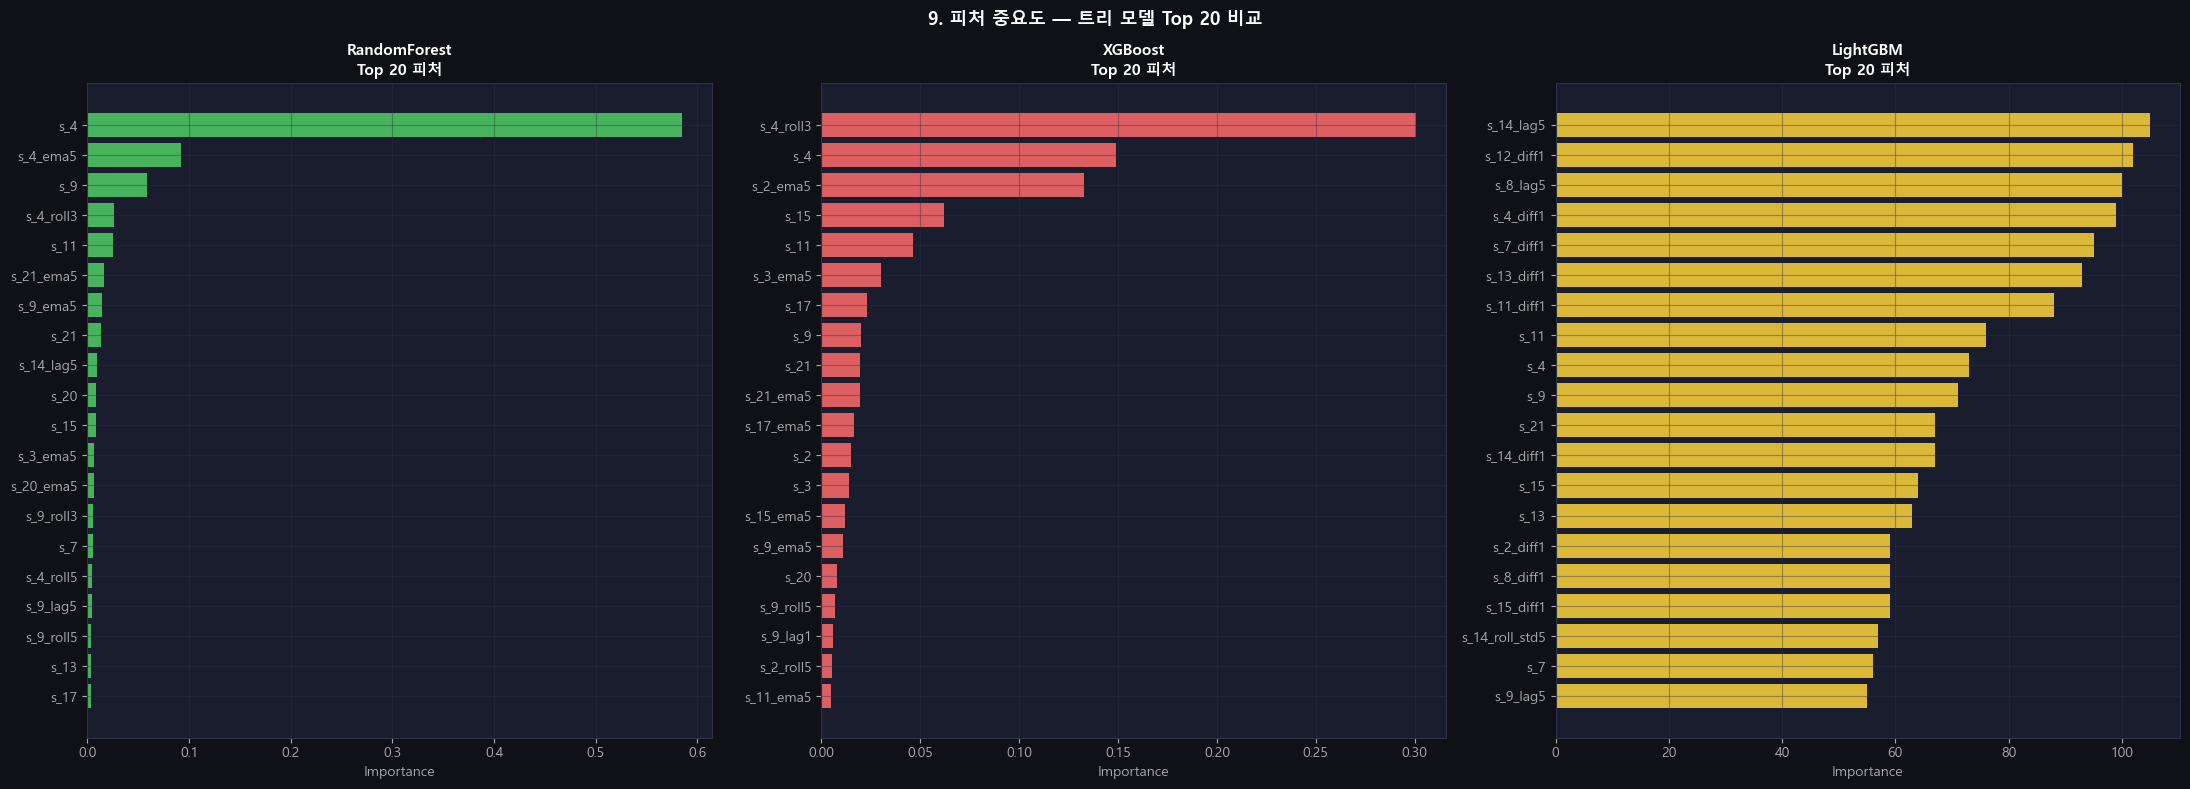


3개 트리 모델 공통 Top-10 피처 (3개):
  - s_11
  - s_4
  - s_9


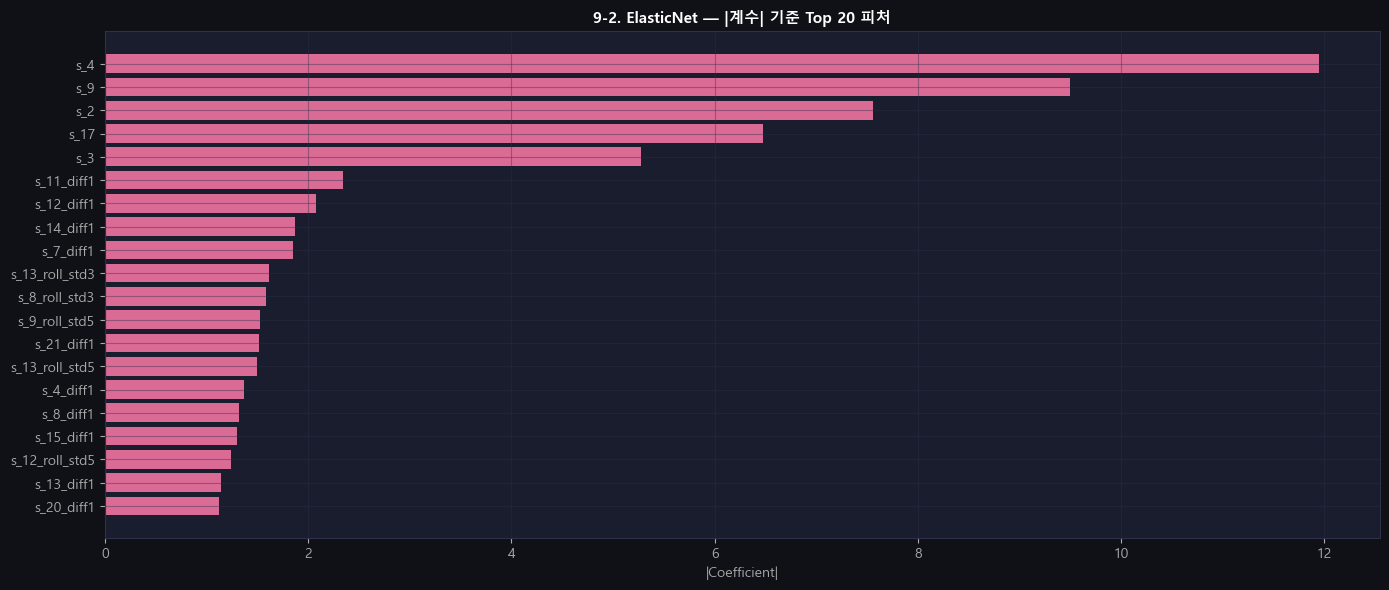

In [12]:
print('=== 9. 피처 중요도 분석 ===')

# ── 트리 3개 나란히 비교 ────────────────────────────────────────────
TOP_N   = 20
tree_names = ['RandomForest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle(f'9. 피처 중요도 — 트리 모델 Top {TOP_N} 비교', fontsize=13, fontweight='bold')

fi_dfs = {}
for ax, mname in zip(axes, tree_names):
    m  = BEST_MODELS[mname]
    fi = pd.Series(m.feature_importances_, index=FEATURES_TREE).nlargest(TOP_N)
    fi_dfs[mname] = fi
    bars = ax.barh(fi.index[::-1], fi.values[::-1],
                   color=MODEL_COLORS[mname], alpha=0.85)
    ax.set_title(f'{mname}\nTop {TOP_N} 피처', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()

# ── 공통 Top 피처 ────────────────────────────────────────────────────
top10_sets = {m: set(fi.nlargest(10).index) for m, fi in fi_dfs.items()}
common_top = top10_sets['RandomForest'] & top10_sets['XGBoost'] & top10_sets['LightGBM']
print(f'\n3개 트리 모델 공통 Top-10 피처 ({len(common_top)}개):')
for f in sorted(common_top):
    print(f'  - {f}')

# ── 선형 모델 베스트 계수 시각화 ───────────────────────────────────────
lin_best_name = min((n for n in ['Ridge','Lasso','ElasticNet']),
                    key=lambda n: ALL_RESULTS[n]['test_metrics']['RMSE'])
lin_model = BEST_MODELS[lin_best_name]

coef = pd.Series(np.abs(lin_model.coef_), index=FEATURES_LINEAR).nlargest(TOP_N)
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(coef.index[::-1], coef.values[::-1], color=MODEL_COLORS[lin_best_name], alpha=0.85)
ax.set_title(f'9-2. {lin_best_name} — |계수| 기준 Top {TOP_N} 피처', fontweight='bold')
ax.set_xlabel('|Coefficient|')
ax.set_facecolor(BG2)
plt.tight_layout(); plt.show()


## 10. 엔진별 RUL 예측 곡선

> Validation 세트 대표 엔진 6대의 RUL 전체 궤적 추적  
> 베스트 모델 vs 실제 RUL 비교


=== 10. 엔진별 RUL 예측 곡선 (Validation) ===
비교 모델: LightGBM (최고 트리) vs ElasticNet (최고 선형)


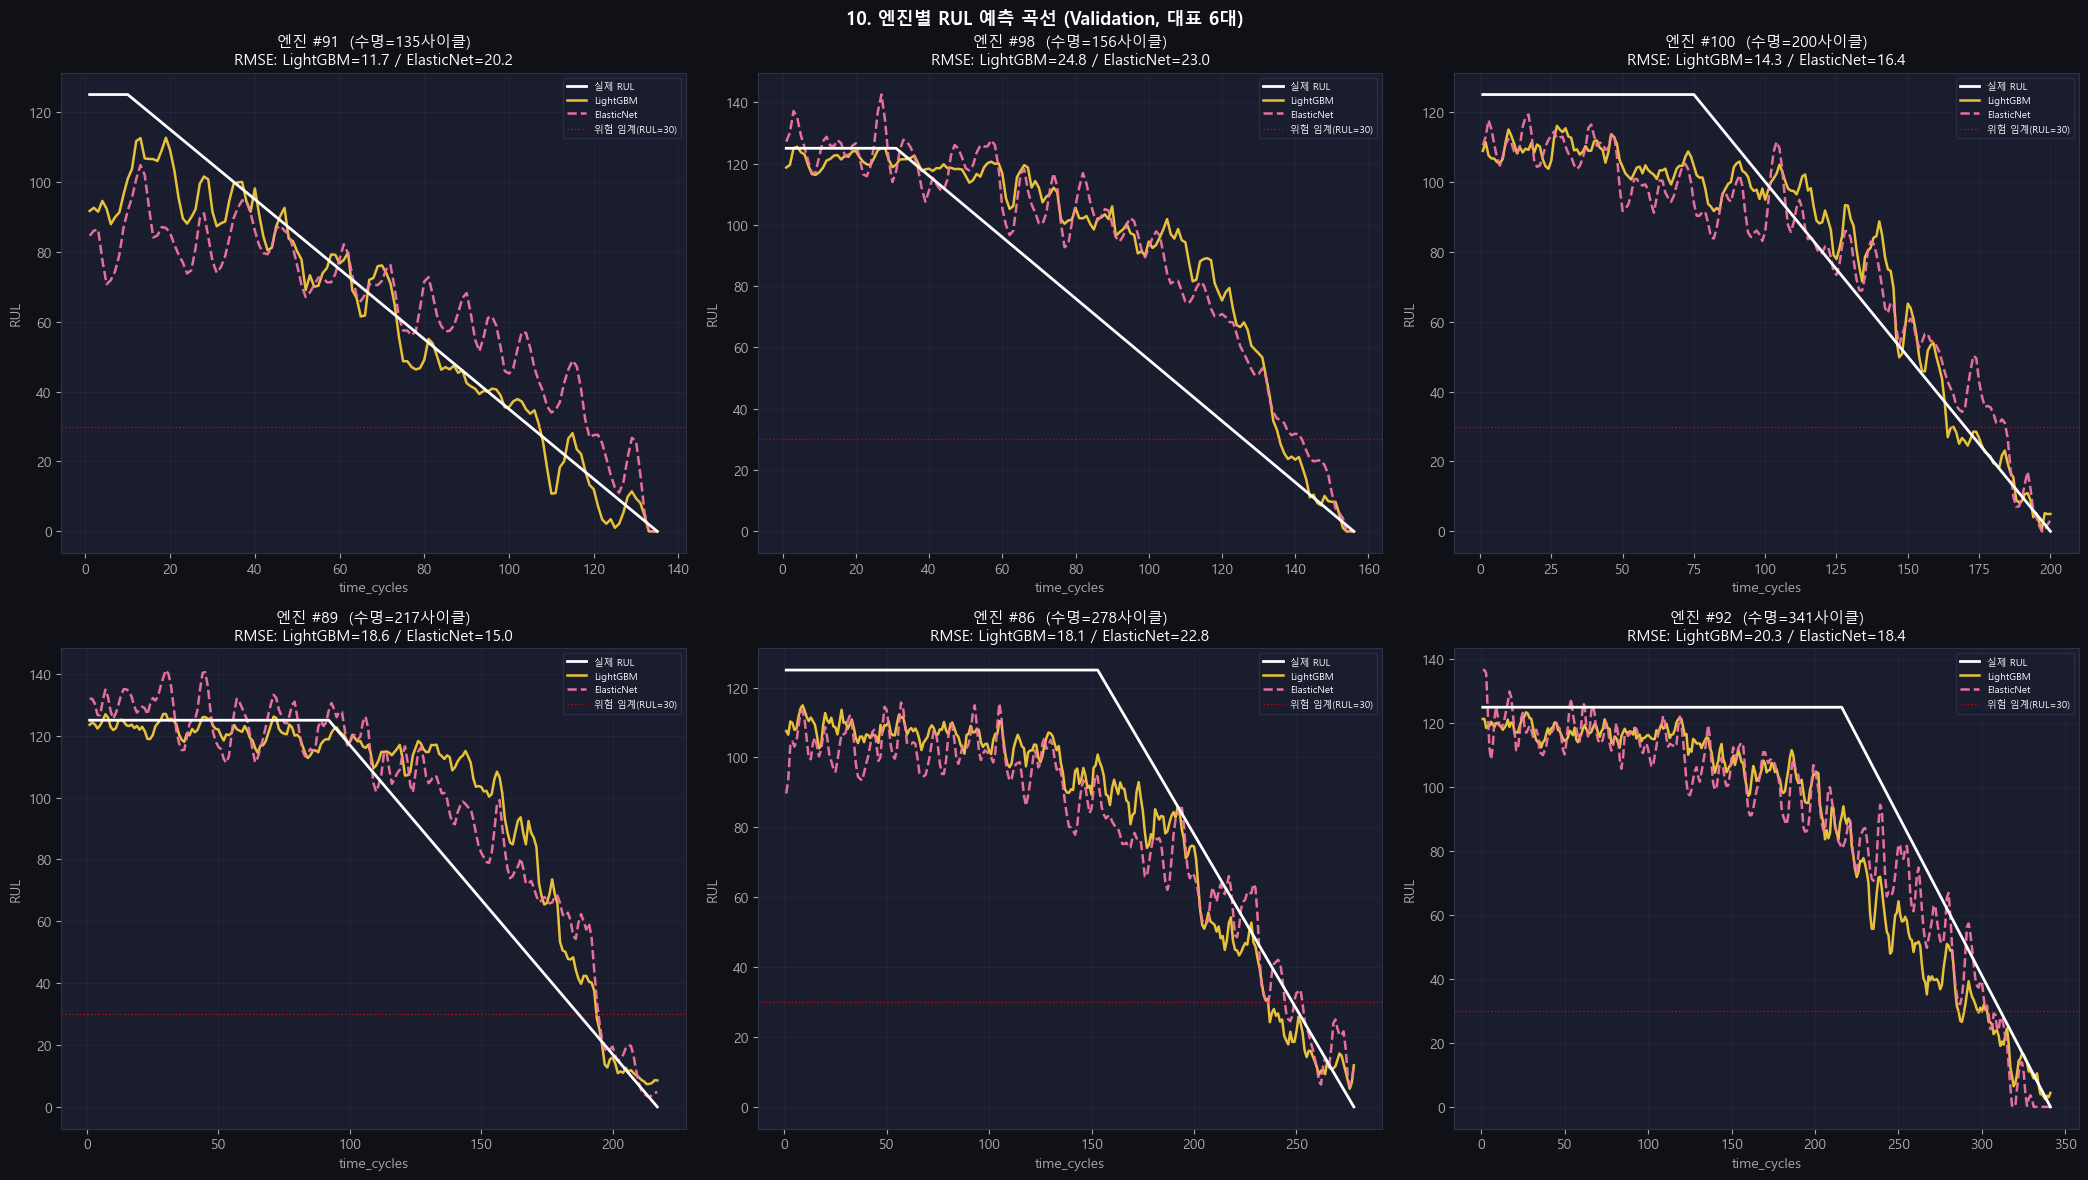

In [13]:
print('=== 10. 엔진별 RUL 예측 곡선 (Validation) ===')

best_tree_name = min(tree_models, key=lambda n: ALL_RESULTS[n]['test_metrics']['RMSE'])
best_lin_name  = min(['Ridge','Lasso','ElasticNet'], key=lambda n: ALL_RESULTS[n]['test_metrics']['RMSE'])

print(f'비교 모델: {best_tree_name} (최고 트리) vs {best_lin_name} (최고 선형)')

# Validation 엔진 중 수명이 다양한 6개 선택
val_lifecycles = valid.groupby('unit_nr')['time_cycles'].max().sort_values()
n_engines   = min(6, len(val_lifecycles))
idx_choices = np.linspace(0, len(val_lifecycles)-1, n_engines, dtype=int)
sel_units   = val_lifecycles.iloc[idx_choices].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle(f'10. 엔진별 RUL 예측 곡선 (Validation, 대표 6대)', fontsize=13, fontweight='bold')

for ax, uid in zip(axes.flat, sel_units):
    udf  = valid[valid['unit_nr'] == uid].sort_values('time_cycles').reset_index(drop=True)
    Xin_tree = udf[FEATURES_TREE]
    Xin_lin  = pd.DataFrame(scaler_lin.transform(udf[FEATURES_LINEAR]),
                            columns=FEATURES_LINEAR)

    pred_tree = np.clip(BEST_MODELS[best_tree_name].predict(Xin_tree), 0, None)
    pred_lin  = np.clip(BEST_MODELS[best_lin_name].predict(Xin_lin),  0, None)

    ax.plot(udf['time_cycles'], udf['RUL'],    color='white',              lw=2,   label='실제 RUL', zorder=3)
    ax.plot(udf['time_cycles'], pred_tree,     color=MODEL_COLORS[best_tree_name], lw=1.8, ls='-',  label=best_tree_name, alpha=0.9)
    ax.plot(udf['time_cycles'], pred_lin,      color=MODEL_COLORS[best_lin_name],  lw=1.8, ls='--', label=best_lin_name,  alpha=0.9)
    ax.axhline(30, color='red', lw=1, ls=':', alpha=0.7, label='위험 임계(RUL=30)')

    rmse_t = np.sqrt(mean_squared_error(udf['RUL'], pred_tree))
    rmse_l = np.sqrt(mean_squared_error(udf['RUL'], pred_lin))
    ax.set_title(f'엔진 #{uid}  (수명={udf["time_cycles"].max()}사이클)\n'
                 f'RMSE: {best_tree_name}={rmse_t:.1f} / {best_lin_name}={rmse_l:.1f}')
    ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()


## 11. NASA Scoring Function 상세 분석

> 늦은 예측(d≥0)에 exp(d/10)-1 / 조기 예측(d<0)에 exp(-d/13)-1  
> 엔진별 점수 분포 + 위험 엔진(늦은 예측 상위) 파악


=== 11. NASA Score 상세 분석 (Test 100대) ===


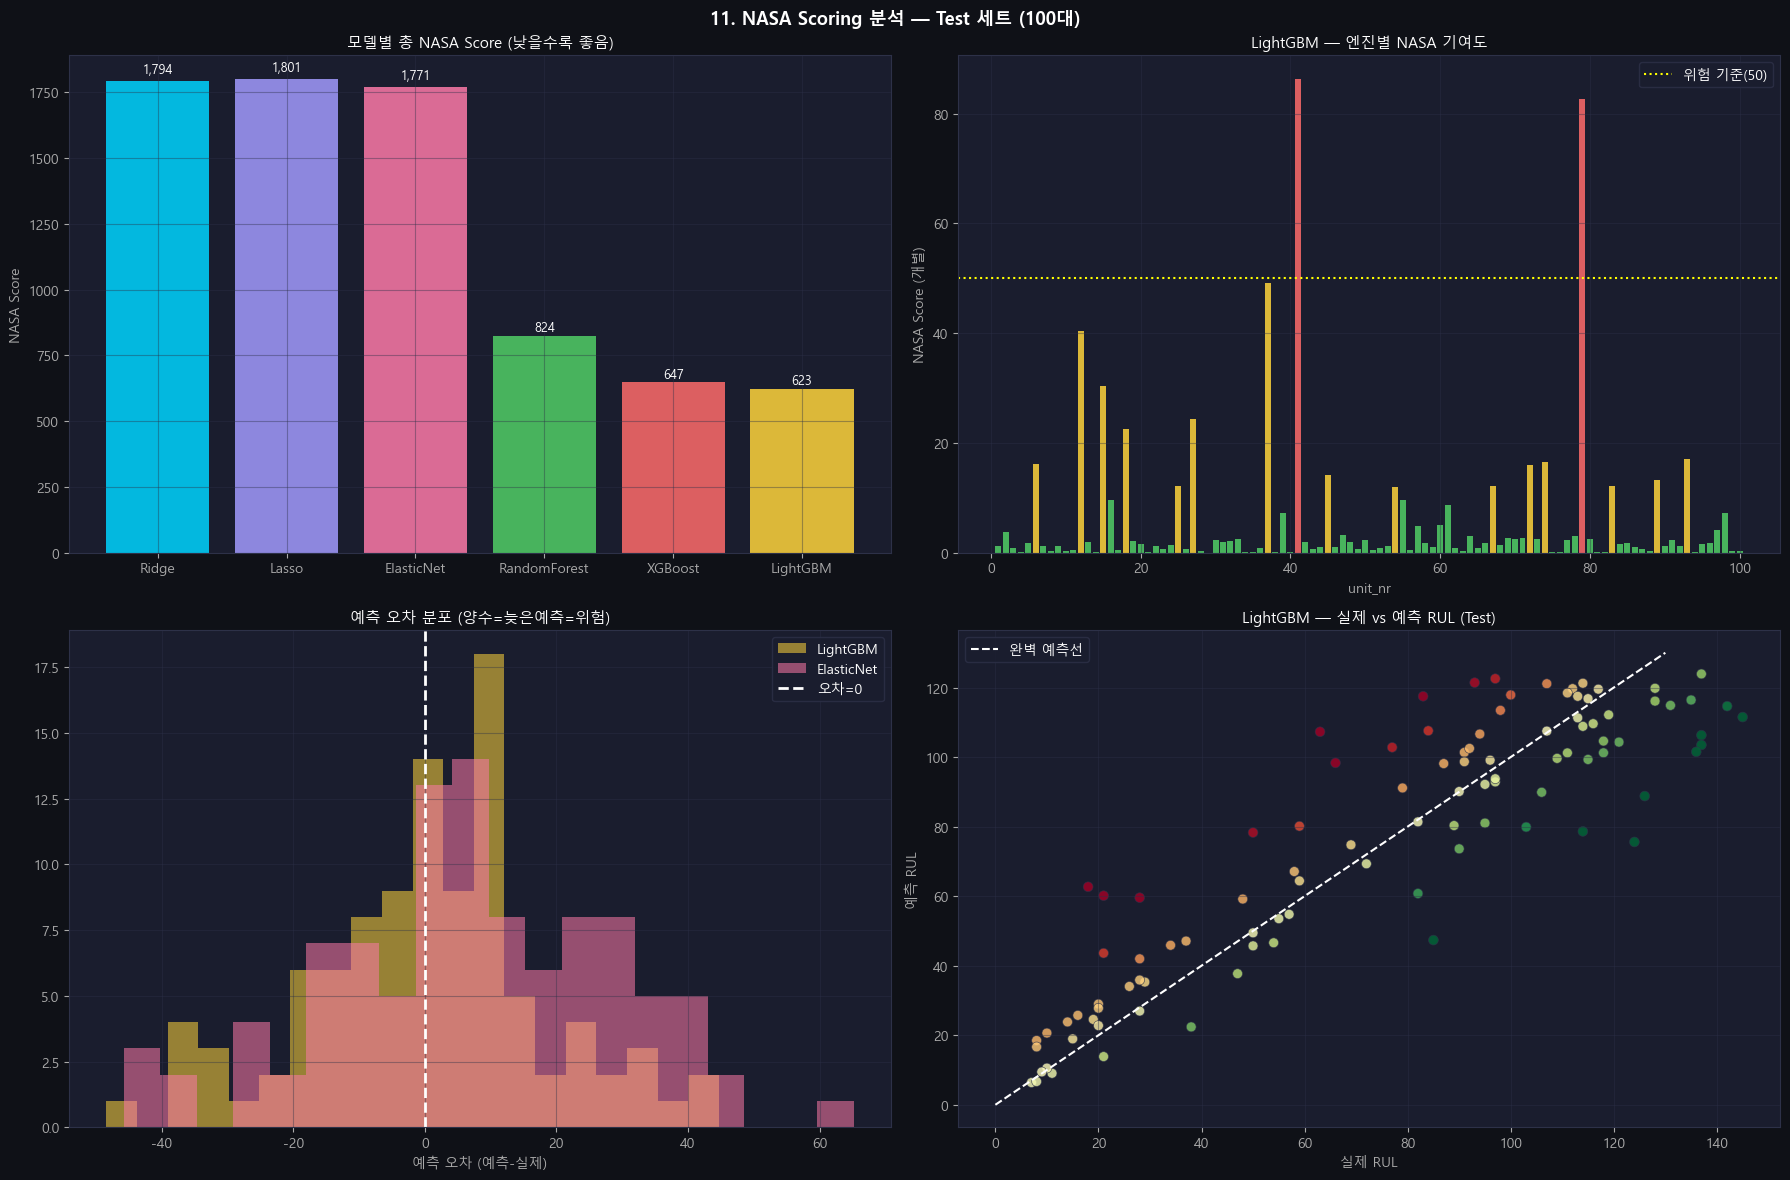


--- 위험 엔진 Top 10 (늦은 예측, 교체 지연 위험) ---


,unit_nr,실제 RUL,예측 RUL,오차(d),NASA기여,위험도
40,41,18,62.7,44.7,86.3,🔴 위험
78,79,63,107.3,44.3,82.7,🔴 위험
36,37,21,60.1,39.1,49.1,🟡 주의
11,12,124,75.6,-48.4,40.4,🟡 주의
14,15,83,117.5,34.5,30.4,🟡 주의
26,27,66,98.3,32.3,24.4,🟡 주의
17,18,28,59.6,31.6,22.5,🟡 주의
92,93,85,47.4,-37.6,17.1,🟡 주의
73,74,126,88.8,-37.2,16.5,🟡 주의
5,6,93,121.4,28.4,16.1,🟡 주의


In [14]:
print('=== 11. NASA Score 상세 분석 (Test 100대) ===')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('11. NASA Scoring 분석 — Test 세트 (100대)', fontsize=13, fontweight='bold')

# ── 모델별 NASA Score 막대 ─────────────────────────────────────────
ax = axes[0,0]
scores = {m: ALL_RESULTS[m]['test_metrics']['NASA_Score'] for m in ALL_RESULTS}
bars   = ax.bar(scores.keys(), scores.values(),
                color=[MODEL_COLORS[m] for m in scores], alpha=0.85)
ax.set_title('모델별 총 NASA Score (낮을수록 좋음)')
ax.set_ylabel('NASA Score')
for bar, v in zip(bars, scores.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,.0f}', ha='center', va='bottom', fontsize=9, color=WHITE)
ax.set_facecolor(BG2)

# ── 최고 트리 모델: 엔진별 NASA 기여도 ─────────────────────────────
ax = axes[0,1]
best_overall = min(ALL_RESULTS, key=lambda n: ALL_RESULTS[n]['test_metrics']['RMSE'])
pred_best = test_pred_all[best_overall]
d     = pred_best - y_test.values
per_engine_ns = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
colors_ns = [C[1] if v > 50 else (C[3] if v > 10 else C[2]) for v in per_engine_ns]
ax.bar(test_eval['unit_nr'], per_engine_ns, color=colors_ns, alpha=0.85)
ax.axhline(50, color='yellow', lw=1.5, ls=':', label='위험 기준(50)')
ax.set_title(f'{best_overall} — 엔진별 NASA 기여도')
ax.set_xlabel('unit_nr'); ax.set_ylabel('NASA Score (개별)')
ax.legend(); ax.set_facecolor(BG2)

# ── 오차 분포 비교 (조기 vs 늦은 예측) ─────────────────────────────
ax = axes[1,0]
for mname in [best_tree_name, best_lin_name]:
    errs = test_pred_all[mname] - y_test.values
    ax.hist(errs, bins=20, alpha=0.55, label=mname,
            color=MODEL_COLORS[mname], edgecolor='none')
ax.axvline(0, color='white', lw=2, ls='--', label='오차=0')
ax.set_title('예측 오차 분포 (양수=늦은예측=위험)')
ax.set_xlabel('예측 오차 (예측-실제)'); ax.legend()
ax.set_facecolor(BG2)

# ── 실제 vs 예측 산점도 (최고 모델) ─────────────────────────────────
ax = axes[1,1]
ax.scatter(y_test, pred_best,
           c=d, cmap='RdYlGn_r', vmin=-30, vmax=30, s=50, alpha=0.8, edgecolors=GRID, lw=0.5)
ax.plot([0,130],[0,130], color='white', lw=1.5, ls='--', label='완벽 예측선')
ax.set_title(f'{best_overall} — 실제 vs 예측 RUL (Test)')
ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL')
ax.legend(); ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()

# 위험 엔진 (늦은 예측 상위 10)
risk_df = pd.DataFrame({
    'unit_nr'  : test_eval['unit_nr'].values,
    '실제 RUL' : y_test.values,
    '예측 RUL' : np.round(pred_best, 1),
    '오차(d)'  : np.round(d, 1),
    'NASA기여'  : np.round(per_engine_ns, 1),
    '위험도'   : ['🔴 위험' if v > 50 else ('🟡 주의' if v > 10 else '🟢 안전') for v in per_engine_ns],
}).sort_values('NASA기여', ascending=False)

print('\n--- 위험 엔진 Top 10 (늦은 예측, 교체 지연 위험) ---')
display(risk_df.head(10))


## 12. 모델 저장


In [15]:
print('=== 12. 모델 저장 ===')

save_dir = 'models'
os.makedirs(save_dir, exist_ok=True)

# 모델 저장
for mname, model in BEST_MODELS.items():
    path = os.path.join(save_dir, f'FD001_{mname}.pkl')
    joblib.dump(model, path)
    size = os.path.getsize(path) / 1024
    print(f'  저장: {path} ({size:.1f} KB)')

# 선형 모델용 scaler 저장
scaler_path = os.path.join(save_dir, 'FD001_scaler_linear.pkl')
joblib.dump(scaler_lin, scaler_path)
print(f'  저장: {scaler_path}')

# 피처 목록 저장
feat_save = os.path.join(save_dir, 'FD001_features_tree.txt')
with open(feat_save, 'w') as f:
    for feat in FEATURES_TREE: f.write(feat+'\n')

feat_lin_save = os.path.join(save_dir, 'FD001_features_linear.txt')
with open(feat_lin_save, 'w') as f:
    for feat in FEATURES_LINEAR: f.write(feat+'\n')

print(f'\n✅ 모델 저장 완료 → {os.path.abspath(save_dir)}/')
print('\n재사용 방법:')
print('  model   = joblib.load("models/FD001_LightGBM.pkl")')
print('  scaler  = joblib.load("models/FD001_scaler_linear.pkl")')
print('  pred    = model.predict(X_new[FEATURES_TREE])')


=== 12. 모델 저장 ===
  저장: models\FD001_Ridge.pkl (1.8 KB)
  저장: models\FD001_Lasso.pkl (1.9 KB)
  저장: models\FD001_ElasticNet.pkl (1.9 KB)
  저장: models\FD001_RandomForest.pkl (25505.0 KB)
  저장: models\FD001_XGBoost.pkl (562.4 KB)
  저장: models\FD001_LightGBM.pkl (393.1 KB)
  저장: models\FD001_scaler_linear.pkl

✅ 모델 저장 완료 → c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\models/

재사용 방법:
  model   = joblib.load("models/FD001_LightGBM.pkl")
  scaler  = joblib.load("models/FD001_scaler_linear.pkl")
  pred    = model.predict(X_new[FEATURES_TREE])


## 13. 최종 요약 리포트


In [16]:
print('=' * 80)
print(' NASA C-MAPSS FD001 — RUL 예측 머신러닝 최종 요약')
print('=' * 80)

print(f'\n[데이터]')
print(f'  Sub-train : {subtrain.shape[0]:,}행  |  엔진 {subtrain["unit_nr"].nunique()}대')
print(f'  Validation: {valid.shape[0]:,}행  |  엔진 {valid["unit_nr"].nunique()}대')
print(f'  Test(eval): {test_eval.shape[0]:,}행  |  엔진 {test_eval["unit_nr"].nunique()}대 (마지막 사이클)')
print(f'  피처(선형): {len(FEATURES_LINEAR)}개  |  피처(트리): {len(FEATURES_TREE)}개')

print(f'\n[모델 성능 최종 순위 — Test RMSE 기준]')
print(f'  {"순위":<4} {"모델":<15} {"Test RMSE":>10} {"Test MAE":>10} {"Test R²":>8} {"NASA":>12}')
print('  ' + '-'*60)
sorted_models = sorted(ALL_RESULTS.items(), key=lambda x: x[1]['test_metrics']['RMSE'])
medals = ['🥇','🥈','🥉','  4.','  5.','  6.']
for i, (mname, res) in enumerate(sorted_models):
    tm = res['test_metrics']
    print(f'  {medals[i]} {mname:<14} {tm["RMSE"]:>10.3f} {tm["MAE"]:>10.3f} {tm["R2"]:>8.4f} {tm["NASA_Score"]:>12.1f}')

print(f'\n[최고 모델: {best_model_name}]')
bm = ALL_RESULTS[best_model_name]
print(f'  CV RMSE  : {bm["cv_rmse"]:.3f}')
print(f'  Val RMSE : {bm["val_metrics"]["RMSE"]:.3f}')
print(f'  Test RMSE: {bm["test_metrics"]["RMSE"]:.3f}')
print(f'  Best Params: {bm["params"]}')

print(f'\n[다음 단계 제안]')
print(f'  1. 딥러닝(LSTM/Transformer) 적용 → 시계열 패턴 직접 학습')
print(f'  2. 앙상블(최고 트리 + 최고 선형) Stacking → 추가 성능 향상 가능')
print(f'  3. FD002/FD003/FD004 다중 조건 데이터셋 확장 적용')
print(f'  4. Shap 값 분석 → 예측 설명 가능성(XAI) 강화')
print('=' * 80)


 NASA C-MAPSS FD001 — RUL 예측 머신러닝 최종 요약

[데이터]
  Sub-train : 16,138행  |  엔진 80대
  Validation: 4,493행  |  엔진 20대
  Test(eval): 100행  |  엔진 100대 (마지막 사이클)
  피처(선형): 48개  |  피처(트리): 140개

[모델 성능 최종 순위 — Test RMSE 기준]
  순위   모델               Test RMSE   Test MAE  Test R²         NASA
  ------------------------------------------------------------
  🥇 LightGBM           18.022     13.713   0.8119        623.3
  🥈 RandomForest       18.190     13.369   0.8084        824.5
  🥉 XGBoost            18.396     13.899   0.8040        647.1
    4. ElasticNet         23.005     18.472   0.6935       1771.1
    5. Ridge              23.058     18.508   0.6921       1793.7
    6. Lasso              23.088     18.533   0.6913       1801.1

[최고 모델: LightGBM]
  CV RMSE  : 17.231
  Val RMSE : 17.745
  Test RMSE: 18.022
  Best Params: {'n_estimators': 454, 'max_depth': 3, 'learning_rate': 0.02136354029924471, 'num_leaves': 53, 'subsample': 0.9974432262903616, 'colsample_bytree': 0.8535972392831754, 'reg_alp